# Proyecto Final — Data Science II

# BTC / DXY / Oro / VIX

## Notebook 02 — Adquisición DXY mediante rangos temporales fijos

Curso: Data Science II — Machine Learning para Ciencia de Datos  
Coderhouse | 2025–2026

---

Este notebook corresponde a la etapa de adquisición definitiva de datos del DXY para el proyecto BTC/DXY/Oro/VIX.

El DXY representa el índice del dólar estadounidense y será utilizado como variable macro-financiera de comparación frente al comportamiento de Bitcoin.

La finalidad de este bloque es construir un dataset reproducible, validado y exportable, manteniendo la misma lógica modular aplicada previamente en el notebook de BTC.

El dataset obtenido en este notebook formará parte de la Fase 1 del pipeline maestro del proyecto y será utilizado posteriormente en la integración multi-activo.

---

# Contexto metodológico

En el notebook anterior se consolidó la estructura base del pipeline modular:

- adquisición mediante rango temporal fijo,
- validación estructural y temporal,
- construcción de variables iniciales,
- logging básico,
- y export del dataset procesado.

En este notebook se reutiliza esa arquitectura para adquirir y validar datos históricos del DXY.

La decisión metodológica principal es mantener consistencia entre activos, utilizando:

- el mismo rango temporal oficial,
- la misma frecuencia diaria,
- una estructura de validación comparable,
- y un output procesado reutilizable para etapas posteriores.

---

# Rango temporal y fuente de datos

El rango temporal oficial del proyecto será:

| Inicio | Fin |
|---|---|
| 2023-05-06 | 2026-05-06 |

Frecuencia:
- diaria

Fuente:
- Yahoo Finance mediante `yfinance`

Ticker utilizado:
- `DX-Y.NYB`

---

El uso de Yahoo Finance permite mantener una estrategia de adquisición consistente con el módulo BTC, evitando restricciones de acceso histórico detectadas previamente en otras APIs gratuitas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os

# 1. Adquisición de datos desde Yahoo Finance y definición de ticker.

In [2]:
ticker = "DX-Y.NYB"

dxy_df = yf.download(
    ticker,
    start="2023-05-06",
    end="2026-05-07"
)

[*********************100%***********************]  1 of 1 completed


In [3]:
dxy_df.head()

Price,Close,High,Low,Open,Volume
Ticker,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB
Date,,,,,
2023-05-08,101.370003,101.419998,101.040001,101.279999,0
2023-05-09,101.639999,101.839996,101.360001,101.400002,0
2023-05-10,101.480003,101.809998,101.220001,101.620003,0
2023-05-11,102.059998,102.150002,101.300003,101.410004,0
2023-05-12,102.680000,102.709999,101.940002,102.099998,0


# 2. Exploración inicial y simplificación de la estructura MultiIndex

In [4]:
dxy_df.columns = dxy_df.columns.droplevel(1)

In [5]:
dxy_df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-05-08,101.370003,101.419998,101.040001,101.279999,0
2023-05-09,101.639999,101.839996,101.360001,101.400002,0
2023-05-10,101.480003,101.809998,101.220001,101.620003,0
2023-05-11,102.059998,102.150002,101.300003,101.410004,0
2023-05-12,102.680000,102.709999,101.940002,102.099998,0


In [6]:
dxy_df.columns.name = None

In [7]:
dxy_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

# 3. Validación estructural y temporal del dataset DXY

Antes de continuar con la construcción de features y análisis exploratorio, se realizan validaciones básicas de integridad estructural sobre el dataset adquirido.

Las siguientes verificaciones buscan confirmar:

- consistencia temporal,
- ausencia de duplicados,
- continuidad del rango temporal,
- y coherencia general de la estructura del dataset.

In [23]:
print("=== VALIDACIÓN ESTRUCTURAL DXY ===")

print(f"Shape del dataset: {dxy_df.shape}")

print(
    f"Rango temporal: "
    f"{dxy_df.index.min().date()} "
    f"→ "
    f"{dxy_df.index.max().date()}"
)

print(
    f"Orden cronológico correcto: "
    f"{dxy_df.index.is_monotonic_increasing}"
)

print(
    f"Duplicados temporales: "
    f"{dxy_df.index.duplicated().sum()}"
)

print(
    f"Gaps temporales detectados: "
    f"{(dxy_df.index.to_series().diff().dropna() != pd.Timedelta(days=1)).sum()}"
)

print(
    "Nota: en DXY los gaps temporales son esperados por calendario financiero "
    "(fines de semana y feriados)."
)

=== VALIDACIÓN ESTRUCTURAL DXY ===
Shape del dataset: (754, 8)
Rango temporal: 2023-05-08 → 2026-05-06
Orden cronológico correcto: True
Duplicados temporales: 0
Gaps temporales detectados: 167
Nota: en DXY los gaps temporales son esperados por calendario financiero (fines de semana y feriados).


## Interpretación de gaps temporales en DXY

A diferencia de Bitcoin, el DXY pertenece a mercados financieros tradicionales y no opera de manera continua durante fines de semana y ciertos feriados.

Por este motivo, la validación temporal detecta gaps mayores a un día entre registros consecutivos.

En este contexto, dichos gaps representan comportamiento normal del calendario financiero y no ausencia o corrupción de datos.

# 4. Construcción de features iniciales

Luego de validar la integridad estructural y temporal del dataset, se construirán las primeras variables financieras derivadas del DXY.

Estas variables permitirán:

- medir variaciones porcentuales diarias,
- estimar volatilidad reciente,
- y suavizar comportamiento del índice mediante medias móviles.

Las features construidas en esta etapa mantienen coherencia metodológica con las utilizadas previamente en el módulo BTC.

### 4.1. Retorno porcentual diario

In [10]:
dxy_df["return"] = dxy_df["Close"].pct_change()

### 4.2. Volatilidad rolling de 7 días

In [11]:
dxy_df["volatility_7d"] = (
    dxy_df["return"]
    .rolling(7)
    .std()
)

### 4.3. Media Movil de 7 días

In [12]:
dxy_df["ma_7d"] = (
    dxy_df["Close"]
    .rolling(7)
    .mean()
)

In [13]:
dxy_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'volatility_7d',
       'ma_7d'],
      dtype='str')

# 5. Validación de features y valores faltantes

Luego de construir las primeras variables financieras derivadas, se validan los valores faltantes generados por operaciones temporales como:

- `pct_change()`
- y ventanas rolling (`rolling()`).

Los NaN esperados forman parte natural de la construcción de features temporales y deben verificarse explícitamente antes de continuar el pipeline.

In [14]:
print("=== VALIDACIÓN DE NaN ===")

print(
    f"NaN en return: "
    f"{dxy_df['return'].isna().sum()}"
)

print(
    f"NaN en volatility_7d: "
    f"{dxy_df['volatility_7d'].isna().sum()}"
)

print(
    f"NaN en ma_7d: "
    f"{dxy_df['ma_7d'].isna().sum()}"
)

=== VALIDACIÓN DE NaN ===
NaN en return: 1
NaN en volatility_7d: 7
NaN en ma_7d: 6


# 6. Visualización inicial del DXY

Se realiza una exploración visual básica del comportamiento temporal del DXY con el objetivo de:

- validar coherencia visual del dataset,
- observar tendencias generales,
- identificar períodos de estabilidad o volatilidad,
- y verificar consistencia general del activo antes de etapas posteriores del pipeline.

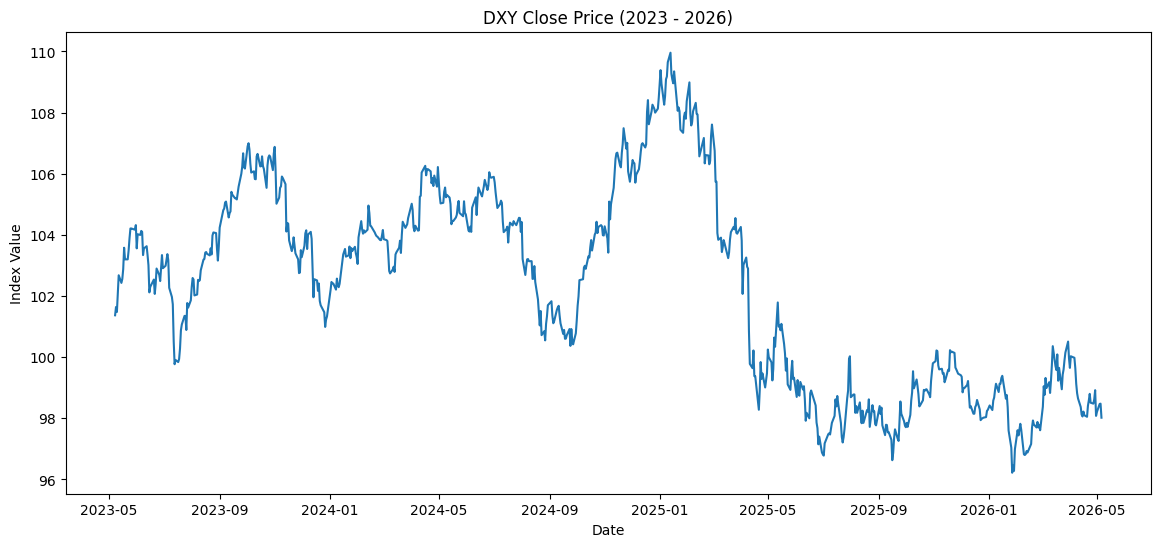

In [15]:
plt.figure(figsize=(14,6))

plt.plot(
    dxy_df.index,
    dxy_df["Close"]
)

plt.title("DXY Close Price (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

## Lectura inicial del comportamiento del DXY

El DXY presenta un comportamiento considerablemente más estable que Bitcoin, aunque mantiene movimientos relevantes dentro del rango temporal analizado.

A diferencia de BTC, el índice no muestra movimientos explosivos ni tendencias parabólicas, sino oscilaciones más contenidas propias de mercados macro-financieros tradicionales.

Durante el período 2023–2026 pueden observarse:

- fases de fortalecimiento progresivo del dólar,
- períodos laterales,
- y etapas de debilitamiento relativamente sostenido.

Es importante destacar que el DXY no mide el valor absoluto del dólar, sino su fortaleza relativa frente a una canasta de monedas internacionales relevantes.

Por lo tanto:

- un movimiento alcista del DXY representa fortalecimiento relativo del dólar,
- mientras que una caída del índice representa debilitamiento relativo frente al conjunto de monedas que componen el índice.

Debido a que las monedas poseen ponderaciones distintas dentro del DXY — especialmente el euro — ciertos movimientos pueden impactar significativamente más en el índice general que otros.

Esta característica será relevante posteriormente al comparar el comportamiento del DXY frente a Bitcoin, Oro y VIX dentro del análisis multi-activo del proyecto.

# 7. Visualización de retornos diarios

Se visualiza la variación porcentual diaria del DXY con el objetivo de observar:

- intensidad de los movimientos diarios,
- estabilidad relativa del índice,
- y comportamiento temporal de los retornos.

Debido a que el DXY pertenece a mercados macro-financieros tradicionales, se espera una volatilidad considerablemente menor respecto a Bitcoin.

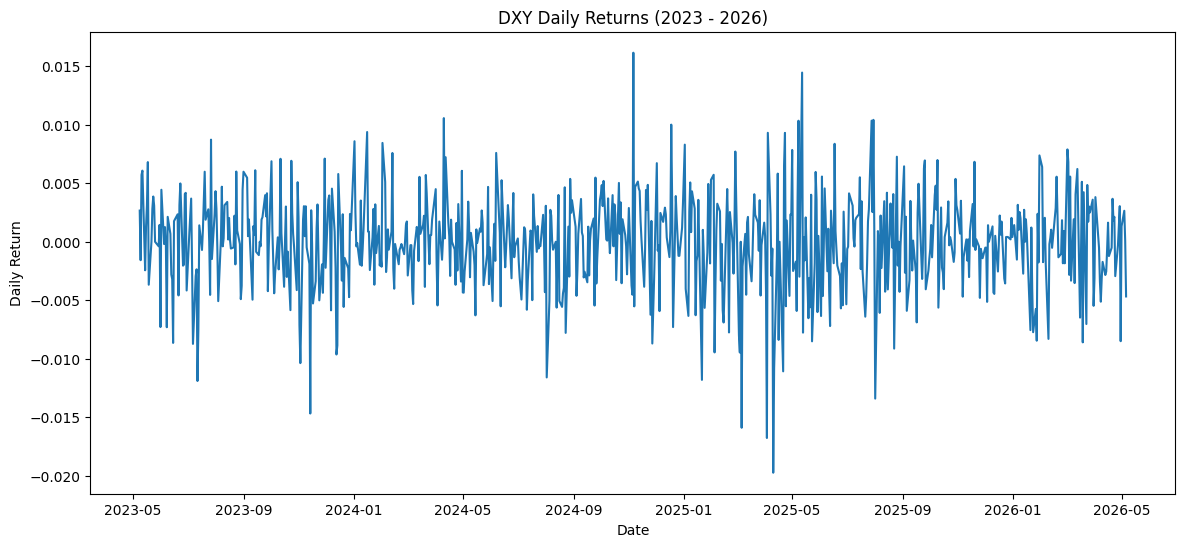

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    dxy_df.index,
    dxy_df["return"]
)

plt.title("DXY Daily Returns (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

## Lectura inicial de retornos diarios del DXY

La visualización de retornos diarios permite contextualizar la verdadera escala de movimiento del DXY respecto a otros activos financieros como Bitcoin.

Aunque el gráfico de precios mostraba oscilaciones relevantes dentro del rango temporal analizado, los retornos diarios evidencian que el índice posee una volatilidad considerablemente menor que BTC.

La mayoría de los movimientos diarios del DXY se mantienen dentro de rangos relativamente pequeños, generalmente inferiores al ±1%, incluso durante períodos de mayor inestabilidad macro-financiera.

Esta diferencia refleja la naturaleza estructural del activo:

- Bitcoin representa un activo altamente especulativo y de elevada volatilidad,
- mientras que el DXY representa un índice macroeconómico asociado a la fortaleza relativa del dólar estadounidense frente a otras monedas internacionales.

También resulta importante destacar que el precio absoluto del DXY no puede compararse directamente con activos cotizados en dólares como BTC u Oro, debido a que el índice representa una medida relativa y no un valor monetario absoluto.

Sin embargo, los retornos porcentuales sí permiten comparar magnitud y comportamiento relativo entre activos distintos, ya que expresan variaciones normalizadas independientemente de la escala de precios original.

# 8. Volatilidad móvil de 7 días

Se visualiza la volatilidad móvil de 7 días del DXY con el objetivo de identificar:

- períodos de mayor tensión macro-financiera,
- cambios en intensidad de movimiento,
- y fases de estabilidad relativa del índice.

La volatilidad rolling permite observar cómo cambia el nivel de dispersión de los retornos a lo largo del tiempo, suavizando el ruido diario individual.

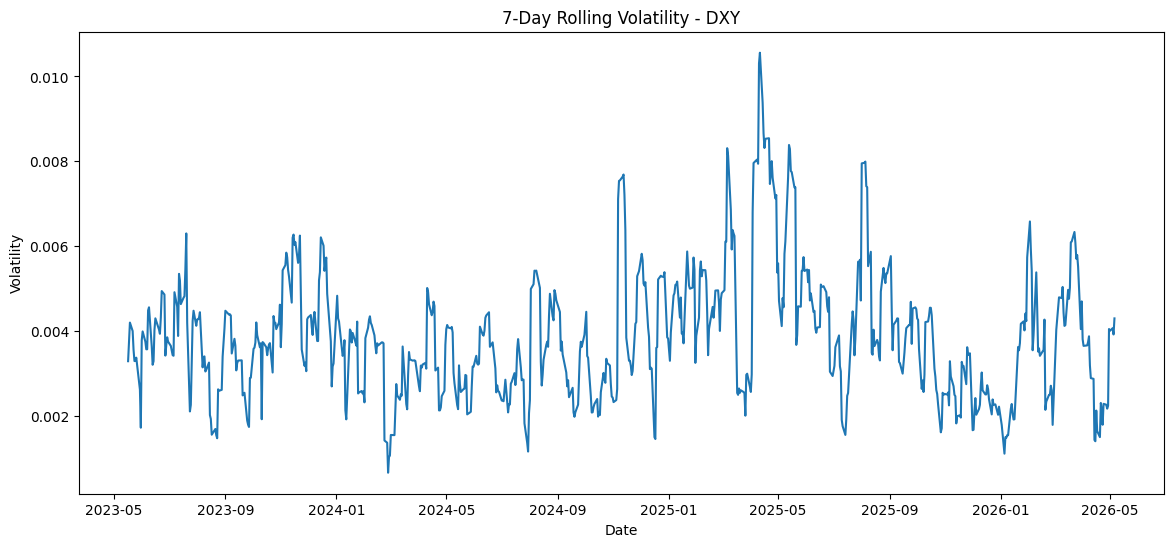

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    dxy_df.index,
    dxy_df["volatility_7d"]
)

plt.title("7-Day Rolling Volatility - DXY")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

## Lectura inicial de volatilidad móvil del DXY

La volatilidad móvil de 7 días permite identificar períodos donde el DXY presentó mayores niveles de tensión e inestabilidad relativa dentro de su propio comportamiento histórico.

El tramo comprendido aproximadamente entre diciembre de 2024 y septiembre de 2025 muestra los valores de volatilidad más elevados del período analizado, evidenciando una etapa de mayor dispersión en los retornos diarios del índice.

Sin embargo, incluso en sus momentos de mayor volatilidad, el DXY continúa mostrando movimientos considerablemente menores en comparación con Bitcoin.

Mientras que BTC puede alcanzar volatilidades extremadamente elevadas asociadas a movimientos diarios explosivos, el DXY mantiene oscilaciones mucho más contenidas debido a su naturaleza macro-financiera y al rol estructural del dólar dentro del sistema financiero internacional.

Esto refuerza la diferencia de comportamiento entre ambos activos:

- Bitcoin presenta una dinámica altamente especulativa y acelerada,
- mientras que el DXY opera como un índice macroeconómico de movimientos más lentos pero potencialmente muy influyentes sobre otros mercados.

La comparación entre ambos activos sugiere que pequeñas variaciones relativas en el DXY pueden coexistir con movimientos mucho más agresivos en Bitcoin, aspecto que será relevante en etapas posteriores del análisis multi-activo.

# 9. Media móvil de 7 días

Se visualiza la media móvil de 7 días del DXY con el objetivo de suavizar fluctuaciones diarias y observar con mayor claridad el comportamiento tendencial del índice.

La media móvil permite reducir parte del ruido presente en los retornos diarios y facilita la identificación de:

- tendencias generales,
- cambios progresivos de dirección,
- y períodos de fortalecimiento o debilitamiento sostenido del dólar.

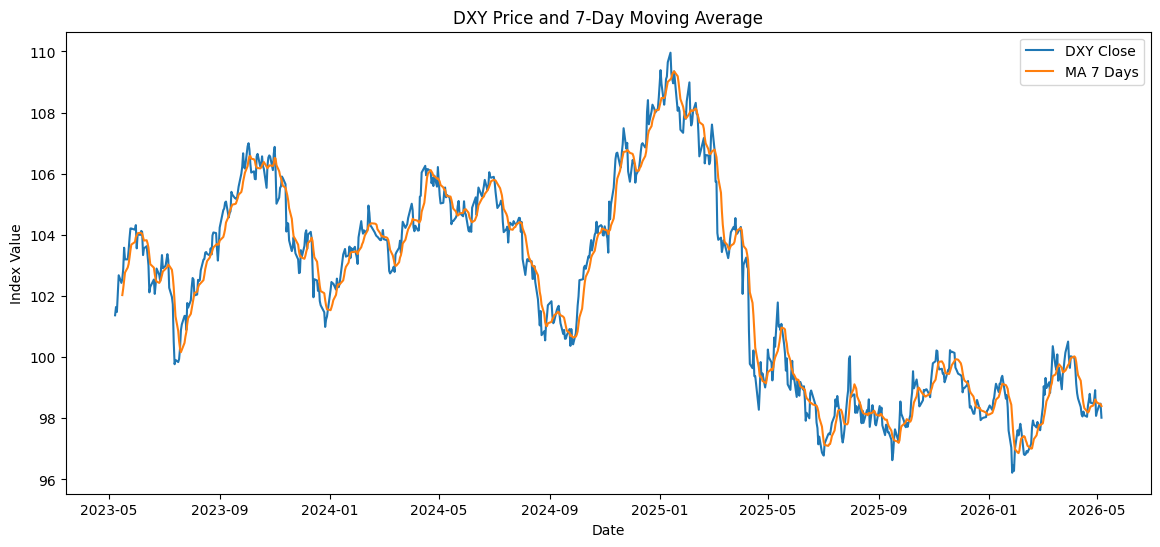

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    dxy_df.index,
    dxy_df["Close"],
    label="DXY Close"
)

plt.plot(
    dxy_df.index,
    dxy_df["ma_7d"],
    label="MA 7 Days"
)

plt.title("DXY Price and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()

plt.show()

## Lectura inicial de la media móvil del DXY

La media móvil de 7 días muestra un comportamiento considerablemente más cercano al precio real del activo en comparación con lo observado previamente en Bitcoin.

Esto ocurre debido a que el DXY presenta una volatilidad estructural mucho menor, generando fluctuaciones diarias más contenidas y reduciendo la necesidad de suavización extrema.

A lo largo del período analizado pueden observarse:

- fases de fortalecimiento progresivo del dólar,
- períodos de debilitamiento relativamente sostenido,
- y múltiples etapas laterales donde el índice oscila dentro de rangos relativamente estables.

Aunque el DXY experimenta movimientos relevantes dentro del contexto macro-financiero, su comportamiento general continúa siendo mucho más estable y menos explosivo que el de Bitcoin.

La media móvil permite visualizar con mayor claridad que, pese a los movimientos intermedios, el índice mantuvo durante gran parte del período una dinámica relativamente lateral en comparación con activos de naturaleza más especulativa.

Esta diferencia estructural entre ambos activos será importante en futuras etapas del análisis multi-activo y modelado financiero.

# 10. Export del dataset procesado

Luego de finalizar la adquisición, validación y construcción inicial de features, el dataset procesado del DXY será exportado hacia la carpeta `data/processed/`.

Este archivo funcionará como input reutilizable para las siguientes etapas del pipeline multi-activo del proyecto.

In [20]:
PROJECT_PATH = (
    r"C:\DS2_BTC_DXY_ORO_VIX"
)

In [22]:
processed_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

os.makedirs(processed_path, exist_ok=True)

dxy_df.to_csv(
    os.path.join(
        processed_path,
        "dxy_processed.csv"
    ),
    encoding="utf-8-sig"
)

print("=== EXPORT FINALIZADO ===")

print("Archivo exportado correctamente hacia:")

print(
    os.path.join(
        processed_path,
        "dxy_processed.csv"
    )
)

=== EXPORT FINALIZADO ===
Archivo exportado correctamente hacia:
C:\Users\amilc\OneDrive\DATA SCIENCE II\PROYECTO FINAL DS 2\DS2_BTC_DXY_ORO_VIX\data\processed\dxy_processed.csv
